In [14]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [15]:
from src.evaluation import build_predictions_report

In [16]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [17]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl
level_04_daily_dept_sales_artifact.pkl
level_06_daily_store_sales_artifact.pkl


In [18]:
ARTIFACT = "level_06_daily_store_sales_artifact"

In [19]:
import joblib

from src.data.split import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-08-30 16:22:05.926 | INFO     | src.data.split:load_data:359 - level_06_daily_store | target=sales | 19,410 filas | 191 features (9 categóricas)
2026-08-30 16:22:06.177 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 18,850 rows)
2026-08-30 16:22:06.184 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 280 rows)
2026-08-30 16:22:06.187 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 280 rows)
2026-08-30 16:22:07.322 | INFO     | src.data.split:split_data:421 - Features: 161 (5 categóricas)


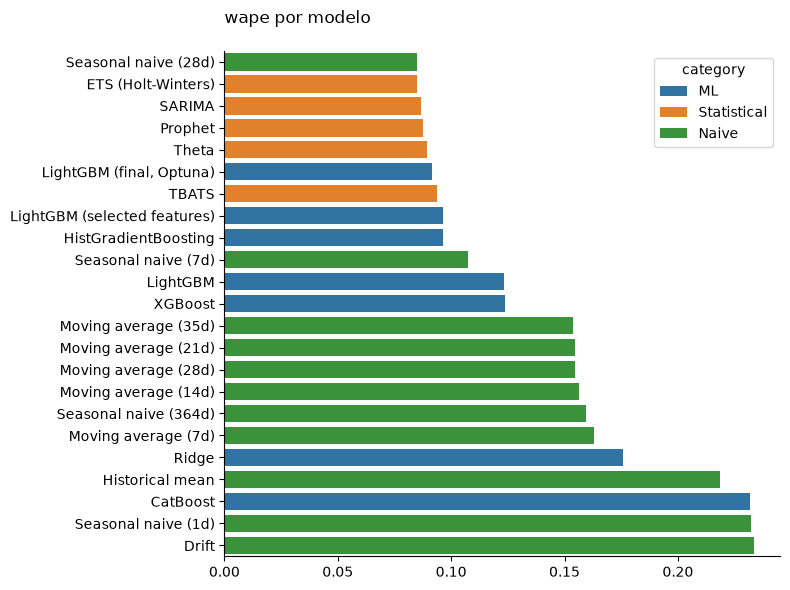

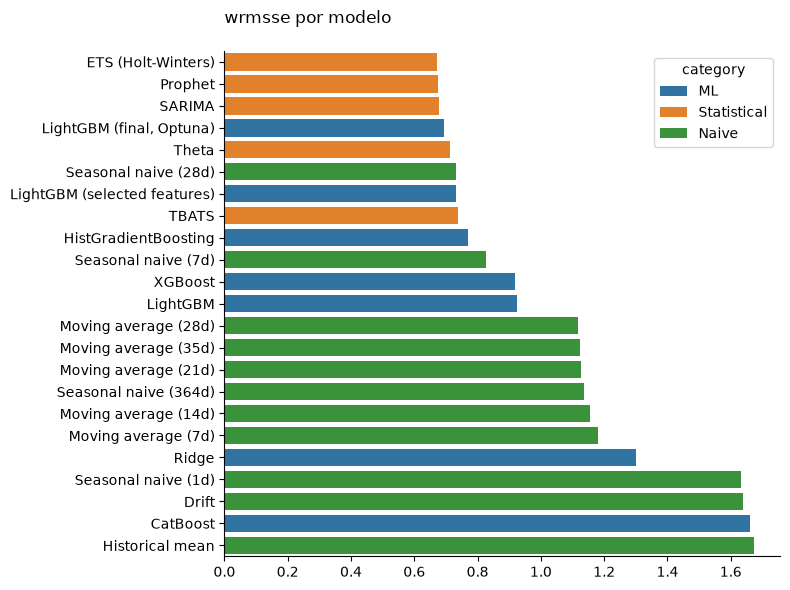

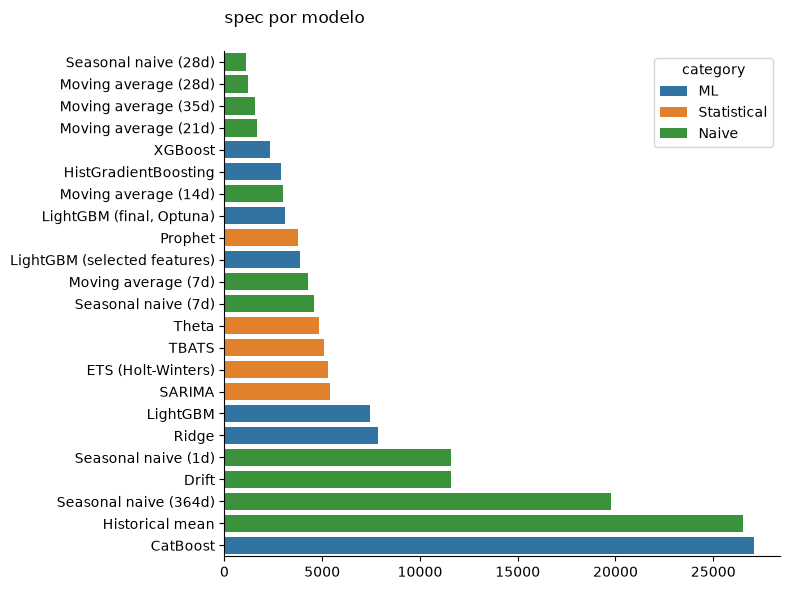

In [20]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [21]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(300_000, len(X_test)), random_state=42)

shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                             feature  mean_abs_shap
64                             lag28     536.338514
45                              lag7     167.475256
68                             lag91     127.883053
69                            lag182      87.036037
9                               snap      86.160208
..                               ...            ...
4                       event_type_2       0.000000
27                   is_store_closed       0.000000
37                       zero_streak       0.000000
128   rolling_min_lag7_window_size14       0.000000
105  rolling_mean_lag4_window_size14       0.000000

[161 rows x 2 columns]


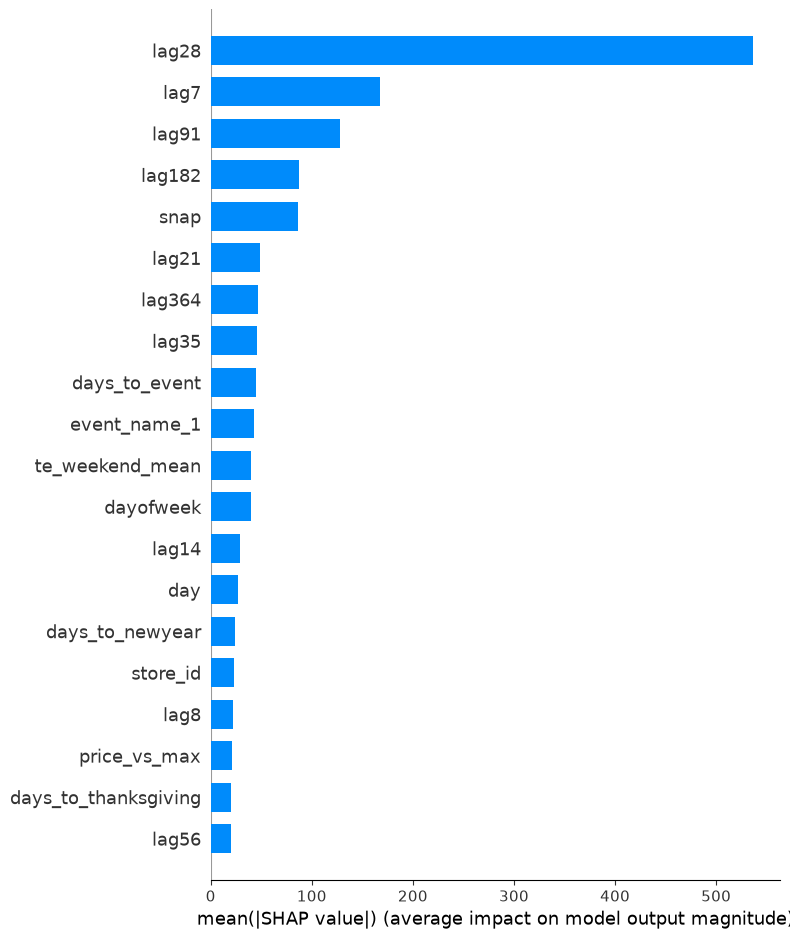

In [22]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


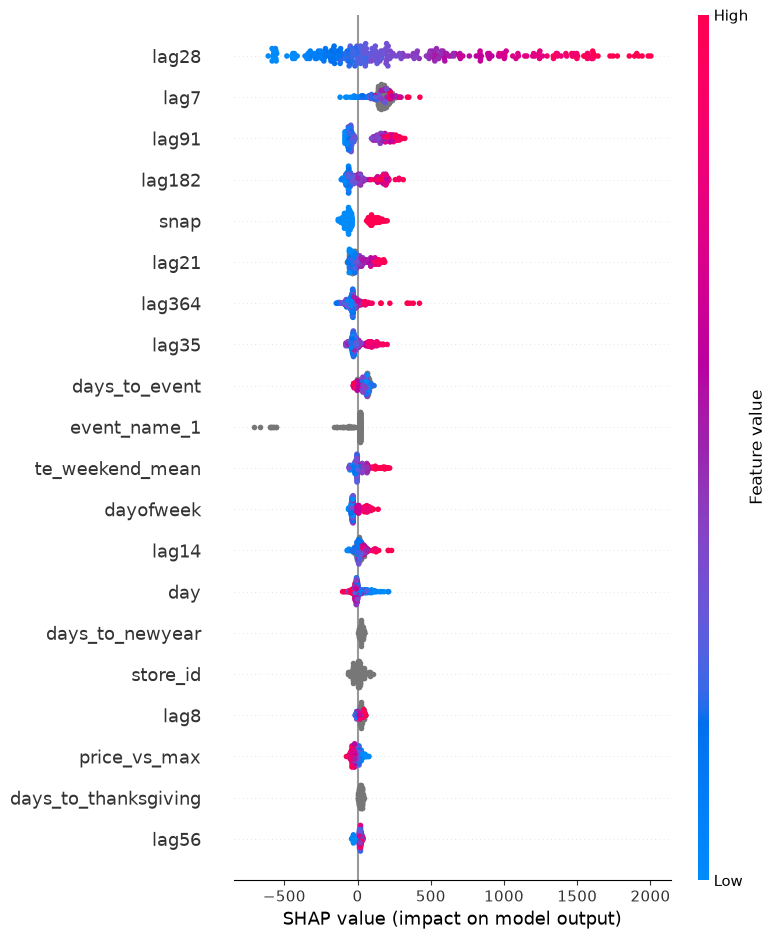

In [23]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [24]:
from src.evaluation import analizar_prediccion, plot_forecast

In [25]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Total sales: {df_pred['sales'].sum():,.0f}")
print(f"Total predicted: {df_pred['y_pred'].sum():,.0f}")
print(f"Diff: {df_pred['y_pred'].sum() - df_pred['sales'].sum():,.0f}")

print(f"Test WAPE: {metrics_test_final['wape']:.1%}")
print(f"Test BIAS: {metrics_test_final['bias']:.1%}")

print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.3f}")

Total sales: 1,231,764
Total predicted: 1,200,852
Diff: -30,912
Test WAPE: 6.3%
Test BIAS: -2.5%
Test WRMSSE: 0.530


In [26]:
from src.evaluation import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
CA_3_CA,28,28,175360.0,173596.0,1764.0,8866.0,590417.93750,0.151351,0.050559,-0.010059,0.068223,5.570945,0.495371,0.449691,263.017857
WI_2_WI,28,28,153976.0,149158.0,4818.0,12302.0,441246.71875,0.113112,0.079896,-0.031291,0.100964,10.966022,0.950893,0.842850,2062.473214
CA_2_CA,28,28,132920.0,129493.0,3427.0,8507.0,438764.71875,0.112476,0.064001,-0.025782,0.073841,11.279652,0.643820,0.580662,347.553571
CA_1_CA,28,28,134032.0,130767.0,3265.0,6515.0,434031.37500,0.111262,0.048608,-0.024360,0.059704,14.032233,0.393958,0.358109,573.214286
TX_3_TX,28,28,116610.0,108543.0,8067.0,9895.0,393570.93750,0.100890,0.084856,-0.069179,0.103603,22.827287,0.774841,0.835713,3118.714286


In [27]:
df_metrics.sort_values('wape')

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
CA_1_CA,28,28,134032.0,130767.0,3265.0,6515.0,434031.375000,0.111262,0.048608,-0.024360,0.059704,14.032233,0.393958,0.358109,573.214286
CA_3_CA,28,28,175360.0,173596.0,1764.0,8866.0,590417.937500,0.151351,0.050559,-0.010059,0.068223,5.570945,0.495371,0.449691,263.017857
CA_4_CA,28,28,78858.0,79398.0,-540.0,4200.0,258581.296875,0.066286,0.053260,0.006848,0.061467,-3.600000,0.565718,0.644899,136.910714
WI_3_WI,28,28,114775.0,113515.0,1260.0,6720.0,323220.062500,0.082856,0.058549,-0.010978,0.067505,5.250000,0.450973,0.446789,253.366071
WI_1_WI,28,28,112444.0,110341.0,2103.0,6753.0,338198.781250,0.086696,0.060057,-0.018703,0.073016,8.719680,0.413676,0.474953,850.633929
TX_1_TX,28,28,97531.0,94373.0,3158.0,6194.0,308179.062500,0.079001,0.063508,-0.032379,0.074917,14.275751,0.522382,0.500210,876.776786
CA_2_CA,28,28,132920.0,129493.0,3427.0,8507.0,438764.718750,0.112476,0.064001,-0.025782,0.073841,11.279652,0.643820,0.580662,347.553571
TX_2_TX,28,28,115258.0,111668.0,3590.0,7544.0,374765.062500,0.096070,0.065453,-0.031148,0.078175,13.324496,0.432050,0.486157,1271.383929
WI_2_WI,28,28,153976.0,149158.0,4818.0,12302.0,441246.718750,0.113112,0.079896,-0.031291,0.100964,10.966022,0.950893,0.842850,2062.473214


/tmp/ipykernel_378229/1163902626.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_sample = df_pred.query(f'series_id == "{SERIES}"').round(2).copy()


,series_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias


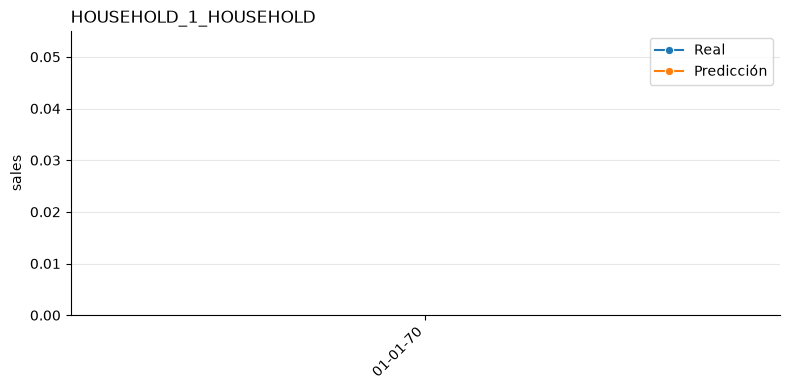

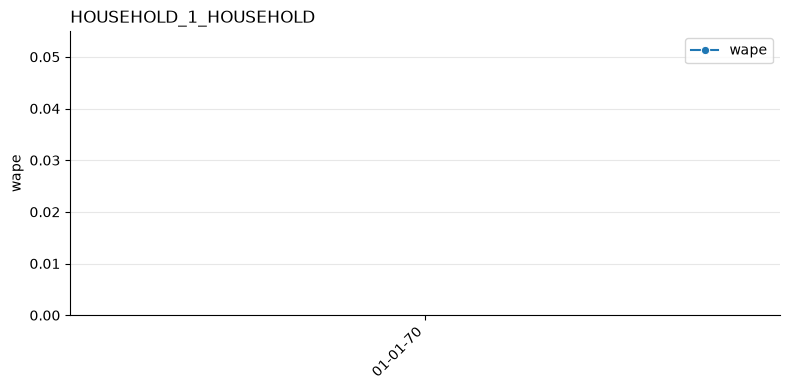

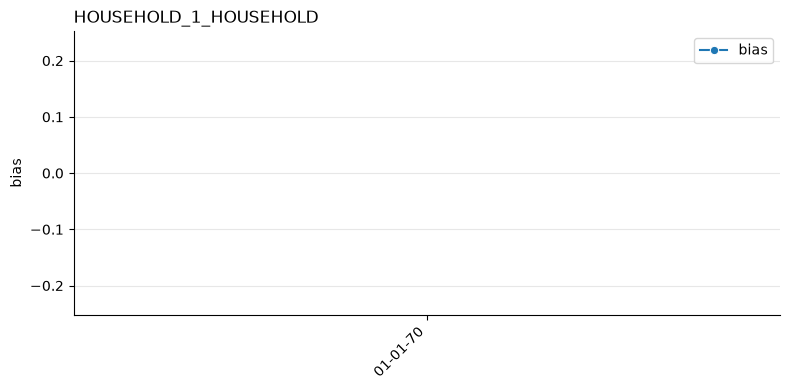

In [28]:
SERIES = 'HOUSEHOLD_1_HOUSEHOLD'
df_sample = df_pred.query(f'series_id == "{SERIES}"').round(2).copy()

display(df_sample)

top_best_dates = df_pred.query(f'series_id == "{SERIES}"').nsmallest(2, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{SERIES}"').nlargest(2, 'wape')['date']

plot_forecast(df_pred, 'sales', series_id=SERIES)
plot_forecast(df_pred, 'wape', series_id=SERIES)
plot_forecast(df_pred, 'bias', series_id=SERIES)

In [29]:
for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)

In [30]:
for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)